# 03 — Evaluation

Evaluates the RAG system against a hand-crafted golden test set of 55 factual
questions with exact verified answers pulled directly from scraped documents.

Tests **6 system variations**:
- 3 chunking strategies × 2 retrieval methods
  - Chunking: Large (2048 chars) | Small (512 chars) | Sentence (NLTK)
  - Retrieval: Semantic (vector similarity) | Keyword (BM25)
- Plus 1 baseline: vanilla GPT with no retrieval


## Setup: Install Dependencies

In [1]:
!pip install -q langchain-community langchain-openai langchain langchain-text-splitters python-dotenv sentence-transformers chromadb pandas rapidfuzz rank-bm25
print("✓ Dependencies installed")


✓ Dependencies installed


## Step 0: Configure API Key

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

if os.getenv("OPENAI_API_KEY") and os.getenv("OPENAI_API_KEY").startswith("sk-"):
    print("✓ OpenAI API key configured")
else:
    raise ValueError("Missing OpenAI API key")


✓ OpenAI API key configured


## Step 1: Imports

In [3]:
from typing import List
from langchain_community.vectorstores import Chroma
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from rank_bm25 import BM25Okapi
from rapidfuzz import fuzz
import pandas as pd
import json
import os



/Users/ghaithalramahi/Downloads/DS593 Final Project/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Load Embedding Model

In [4]:
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

print("✓ Embedding model loaded: text-embedding-3-small")


✓ Embedding model loaded: text-embedding-3-small


## Step 3: Load Existing Vector Databases



In [5]:
CHROMA_DIRS = {
    "large":    "chroma_db",
    "small":    "chroma_db_small",
    "sentence": "chroma_db_sentence",
}

vector_dbs = {}
for name, path in CHROMA_DIRS.items():
    try:
        vdb = Chroma(
            collection_name="tos_documents",
            persist_directory=path,
            embedding_function=embedding_model,
        )
        count = vdb._collection.count()
        vector_dbs[name] = vdb
        print(f"  ✓ {name:10s}: {count} chunks  ({path})")
    except Exception as e:
        print(f"  ✗ {name:10s}: could not load — {e}")

print(f"\n✓ {len(vector_dbs)} vector databases loaded")


/var/folders/rn/8t2pnl9j44z62gqwxgnp1sf80000gn/T/ipykernel_50172/2729119862.py:10: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vdb = Chroma(


  ✓ large     : 903 chunks  (chroma_db)
  ✓ small     : 4383 chunks  (chroma_db_small)
  ✓ sentence  : 872 chunks  (chroma_db_sentence)

✓ 3 vector databases loaded


## Step 4: Build BM25 Index




In [6]:
def build_bm25_index(chroma_dir):
    """Build a BM25 index from an existing ChromaDB collection."""
    vdb = Chroma(
        collection_name="tos_documents",
        persist_directory=chroma_dir,
        embedding_function=embedding_model,
    )

    # Pull all documents and metadata from the collection
    data      = vdb._collection.get(include=["documents", "metadatas"])
    docs      = data["documents"]
    metas     = data["metadatas"]

    # Tokenize for BM25
    tokenized = [doc.lower().split() for doc in docs]
    bm25      = BM25Okapi(tokenized)

    return bm25, docs, metas


print("Building BM25 indexes...")
bm25_indexes = {}
for name, path in CHROMA_DIRS.items():
    bm25, docs, metas = build_bm25_index(path)
    bm25_indexes[name] = {"bm25": bm25, "docs": docs, "metas": metas}
    print(f"  ✓ {name:10s}: {len(docs)} docs indexed")

print("\n✓ BM25 indexes built")


Building BM25 indexes...
  ✓ large     : 903 docs indexed
  ✓ small     : 4383 docs indexed
  ✓ sentence  : 872 docs indexed

✓ BM25 indexes built


## Step 5: Initialize LLM

In [7]:
llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.1,
    max_tokens=300
)

print("✓ LLM initialized")


✓ LLM initialized


## Step 6: Define Retrieval + Query Functions

Two retrieval methods, same generation prompt for fair comparison.


In [8]:
def semantic_retrieve(vector_db, query: str, company: str, k: int = 3) -> List[str]:
    """Semantic retrieval using vector similarity search."""
    results = vector_db.similarity_search(
        query,
        k=k,
        filter={"company": company}
    )
    return [doc.page_content for doc in results]


def bm25_retrieve(bm25_index, query: str, company: str, k: int = 3) -> List[str]:
    """Keyword retrieval using BM25 scoring, filtered by company."""
    tokens   = query.lower().split()
    scores   = bm25_index["bm25"].get_scores(tokens)
    docs     = bm25_index["docs"]
    metas    = bm25_index["metas"]

    # Filter to company, rank by BM25 score
    filtered = [
        (i, scores[i])
        for i, meta in enumerate(metas)
        if meta.get("company") == company
    ]
    filtered.sort(key=lambda x: x[1], reverse=True)
    return [docs[i] for i, _ in filtered[:k]]


def generate_answer(chunks: List[str], question: str, company: str) -> str:
    """Generate answer from retrieved chunks — same prompt for all systems."""
    context = "\n\n".join(chunks)
    prompt  = f"""Answer based on these documents:
{context}

Question: {question}

Answer:"""
    return llm.invoke(prompt).content


def baseline_query(question: str, company: str) -> str:
    """Vanilla LLM with no retrieval."""
    prompt = f"""Answer this question about {company}'s Terms of Service or Privacy Policy.
Be direct and specific. If you are not sure, say so.

Question: {question}

Answer:"""
    return llm.invoke(prompt).content


print("✓ All query functions ready")


✓ All query functions ready


## Step 7: Load Golden Test Set

55 factual questions with exact verified answers.


In [9]:
df = pd.read_csv("golden_test_set.csv")

print(f"✓ Loaded {len(df)} questions")
print(f"  Companies: {df['company'].nunique()}")
print(f"\n  Distribution:")
print(df["company"].value_counts().to_string())
print()
print(df[["company", "question", "answer"]].head(8).to_string(index=False))


✓ Loaded 51 questions
  Companies: 9

  Distribution:
company
tinder       6
spotify      6
netflix      6
snapchat     6
paypal       6
linkedin     6
discord      5
twitter_x    5
airbnb       5

  company                                                                       question                                                                     answer
  discord       How many days do you have to opt out of Discord's arbitration agreement?                                                                    30 days
  discord                  Does Discord sell your personal information to third parties?                                                                         No
  discord              What email do you use to opt out of Discord's arbitration clause?                                            arbitration-opt-out@discord.com
  discord                       Does Discord store the contents of video or voice calls?                                                          

## Step 8: Scoring Function


In [ ]:

import json
import re
import numpy as np
from rapidfuzz import fuzz

def cosine_sim(a, b):
    a = np.array(a)
    b = np.array(b)
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

def encoder_similarity_score(model_answer: str, ground_truth: str) -> float:
    emb_pred = embedding_model.embed_query(str(model_answer))
    emb_true = embedding_model.embed_query(str(ground_truth))
    return cosine_sim(emb_pred, emb_true)

def encoder_similarity_correct(model_answer: str, ground_truth: str, threshold: float = 0.82) -> bool:
    score = encoder_similarity_score(model_answer, ground_truth)
    return score >= threshold

def fuzzy_match_score(model_answer: str, ground_truth: str) -> float:
    model = str(model_answer).strip().lower()
    truth = str(ground_truth).strip().lower()
    return float(fuzz.partial_ratio(truth, model)) / 100.0

def fuzzy_match_correct(model_answer: str, ground_truth: str, threshold: float = 0.80) -> bool:
    score = fuzzy_match_score(model_answer, ground_truth)
    return score >= threshold

def llm_judge(question: str, ground_truth: str, model_answer: str) -> tuple[bool, str]:
    prompt = f"""
You are grading a QA system on legal/policy questions.

Question: {question}
Gold answer: {ground_truth}
Predicted answer: {model_answer}

Return JSON only:
{{
  "correct": true or false,
  "reason": "brief explanation"
}}

Mark the prediction as correct if it conveys the same substantive fact as the gold answer,
even if it is paraphrased or longer.

Mark it as incorrect if it contradicts the gold answer, changes the meaning,
or is too vague/uncertain to count as equivalent.
""".strip()

    raw = llm.invoke(prompt).content.strip()

    try:
        match = re.search(r"\{.*\}", raw, re.DOTALL)
        data = json.loads(match.group(0) if match else raw)
        return bool(data["correct"]), data.get("reason", "")
    except Exception:
        return False, "judge parse failed"


# Quick sanity checks
print("Encoder:", encoder_similarity_score("You have 30 days to opt out.", "30 days"))
print("Fuzzy:", fuzzy_match_score("You have 30 days to opt out.", "30 days"))
print("LLM Judge:", llm_judge(
    "How many days do you have to opt out?",
    "30 days",
    "You have 30 days to opt out."
))




NameError: name 'embedding_model' is not defined

## Step 9: Run Evaluation


In [11]:
# Step 9 — Run Evaluation
SYSTEMS = [
    ("large_semantic",    lambda q, c: generate_answer(semantic_retrieve(vector_dbs["large"], q, c), q, c)),
    ("large_bm25",        lambda q, c: generate_answer(bm25_retrieve(bm25_indexes["large"], q, c), q, c)),
    ("small_semantic",    lambda q, c: generate_answer(semantic_retrieve(vector_dbs["small"], q, c), q, c)),
    ("small_bm25",        lambda q, c: generate_answer(bm25_retrieve(bm25_indexes["small"], q, c), q, c)),
    ("sentence_semantic", lambda q, c: generate_answer(semantic_retrieve(vector_dbs["sentence"], q, c), q, c)),
    ("sentence_bm25",     lambda q, c: generate_answer(bm25_retrieve(bm25_indexes["sentence"], q, c), q, c)),
    ("baseline",          lambda q, c: baseline_query(q, c)),
]

for name, _ in SYSTEMS:
    df[f"ans_{name}"] = ""

    df[f"encoder_score_{name}"] = 0.0
    df[f"encoder_correct_{name}"] = False

    df[f"fuzzy_score_{name}"] = 0.0
    df[f"fuzzy_correct_{name}"] = False

    df[f"judge_correct_{name}"] = False
    df[f"judge_reason_{name}"] = ""

for i, row in df.iterrows():
    q = row["question"]
    company = row["company"]
    truth = row["answer"]

    print(f"[{i+1}/{len(df)}] {company} — {q[:55]}...")

    for name, query_fn in SYSTEMS:
        answer = query_fn(q, company)

        enc_score = encoder_similarity_score(answer, truth)
        enc_correct = enc_score >= 0.50

        fuzz_score = fuzzy_match_score(answer, truth)
        fuzz_correct = fuzz_score >= 0.80

        judge_correct, judge_reason = llm_judge(q, truth, answer)

        df.at[i, f"ans_{name}"] = answer

        df.at[i, f"encoder_score_{name}"] = enc_score
        df.at[i, f"encoder_correct_{name}"] = enc_correct

        df.at[i, f"fuzzy_score_{name}"] = fuzz_score
        df.at[i, f"fuzzy_correct_{name}"] = fuzz_correct

        df.at[i, f"judge_correct_{name}"] = judge_correct
        df.at[i, f"judge_reason_{name}"] = judge_reason

print("\n✓ Evaluation complete")




[1/51] discord — How many days do you have to opt out of Discord's arbit...
[2/51] discord — Does Discord sell your personal information to third pa...
[3/51] discord — What email do you use to opt out of Discord's arbitrati...
[4/51] discord — Does Discord store the contents of video or voice calls...
[5/51] discord — What city is Discord Inc. headquartered in?...
[6/51] twitter_x — What is the maximum amount X will pay in damages in a l...
[7/51] twitter_x — What US state's laws govern X's Terms of Service?...
[8/51] twitter_x — How many posts can you access in 24 hours before X char...
[9/51] twitter_x — How long do you have to initiate a federal claim agains...
[10/51] twitter_x — How long do you have to initiate a state law claim agai...
[11/51] tinder — What is the minimum age to use Tinder?...
[12/51] tinder — Does Tinder automatically renew subscriptions?...
[13/51] tinder — If you cancel your Tinder subscription do you lose acce...
[14/51] tinder — Who handles refunds for Appl

# Step 10. Consolidated results output

In [12]:
total = len(df)

rows = []
for name, _ in SYSTEMS:
    encoder_acc = df[f"encoder_correct_{name}"].mean() * 100
    fuzzy_acc   = df[f"fuzzy_correct_{name}"].mean() * 100
    judge_acc   = df[f"judge_correct_{name}"].mean() * 100

    encoder_avg = df[f"encoder_score_{name}"].mean()
    fuzzy_avg   = df[f"fuzzy_score_{name}"].mean()

    rows.append({
        "system": name,
        "encoder_acc_pct": round(encoder_acc, 1),
        "fuzzy_acc_pct": round(fuzzy_acc, 1),
        "judge_acc_pct": round(judge_acc, 1),
        "avg_encoder_score": round(encoder_avg, 3),
        "avg_fuzzy_score": round(fuzzy_avg, 3),
    })

summary_df = pd.DataFrame(rows).sort_values("judge_acc_pct", ascending=False)

print("=" * 90)
print("CONSOLIDATED RESULTS")
print("=" * 90)
print(summary_df.to_string(index=False))

best_encoder = summary_df.sort_values("encoder_acc_pct", ascending=False).iloc[0]
best_fuzzy   = summary_df.sort_values("fuzzy_acc_pct", ascending=False).iloc[0]
best_judge   = summary_df.sort_values("judge_acc_pct", ascending=False).iloc[0]

print("\n" + "=" * 90)
print("BEST SYSTEMS BY SCORING METHOD")
print("=" * 90)
print(f"Best by encoder similarity: {best_encoder['system']} ({best_encoder['encoder_acc_pct']}%)")
print(f"Best by fuzzy matching:     {best_fuzzy['system']} ({best_fuzzy['fuzzy_acc_pct']}%)")
print(f"Best by LLM judge:          {best_judge['system']} ({best_judge['judge_acc_pct']}%)")


CONSOLIDATED RESULTS
           system  encoder_acc_pct  fuzzy_acc_pct  judge_acc_pct  avg_encoder_score  avg_fuzzy_score
sentence_semantic             21.6           80.4           90.2              0.389            0.898
       large_bm25             17.6           78.4           88.2              0.380            0.895
   large_semantic             17.6           76.5           86.3              0.388            0.890
    sentence_bm25             17.6           72.5           86.3              0.374            0.867
   small_semantic             17.6           70.6           76.5              0.383            0.857
       small_bm25             17.6           70.6           74.5              0.368            0.822
         baseline             11.8           45.1           58.8              0.327            0.717

BEST SYSTEMS BY SCORING METHOD
Best by encoder similarity: sentence_semantic (21.6%)
Best by fuzzy matching:     sentence_semantic (80.4%)
Best by LLM judge:          sen

In [13]:
df.to_csv("evaluation_results.csv", index=False)
summary_df.to_csv("evaluation_risk_summary.csv", index=False)
print("✓ Saved evaluation_results.csv")
print("✓ Saved evaluation_risk_summary.csv")

✓ Saved evaluation_results.csv
✓ Saved evaluation_risk_summary.csv


In [14]:
for name, _ in SYSTEMS:
    col = f"encoder_score_{name}"
    print(f"\n{name}")
    print(df[col].describe())



large_semantic
count    51.000000
mean      0.387517
std       0.163504
min       0.114159
25%       0.276317
50%       0.369963
75%       0.466376
max       0.819712
Name: encoder_score_large_semantic, dtype: float64

large_bm25
count    51.000000
mean      0.379831
std       0.155301
min       0.110166
25%       0.296885
50%       0.367089
75%       0.438880
max       0.819712
Name: encoder_score_large_bm25, dtype: float64

small_semantic
count    51.000000
mean      0.383283
std       0.169406
min       0.136723
25%       0.266508
50%       0.367206
75%       0.464404
max       0.819712
Name: encoder_score_small_semantic, dtype: float64

small_bm25
count    51.000000
mean      0.368088
std       0.158135
min       0.124520
25%       0.245325
50%       0.360907
75%       0.462481
max       0.784270
Name: encoder_score_small_bm25, dtype: float64

sentence_semantic
count    51.000000
mean      0.388867
std       0.160758
min       0.128279
25%       0.287050
50%       0.372528
75%    

In [15]:
for name, _ in SYSTEMS:
    print(f"\n{name}")
    display(df[["question", "answer", f"ans_{name}", f"encoder_score_{name}", f"encoder_correct_{name}"]]
            .sort_values(f"encoder_score_{name}", ascending=False)
            .head(10))



large_semantic


,question,answer,ans_large_semantic,encoder_score_large_semantic,encoder_correct_large_semantic
2,What email do you use to opt out of Discord's ...,arbitration-opt-out@discord.com,You can opt out of Discord's arbitration claus...,0.819712,True
30,What email do you use to opt out of Netflix's ...,Opt-Out@netflix.com,You must send your opt-out notice to Opt-Out@n...,0.814191,True
49,Can you have more than one LinkedIn account?,No you may only have one LinkedIn account,"No, you are only allowed to have one LinkedIn ...",0.789209,True
18,If a Host terminates their account what happen...,They are automatically canceled and guests rec...,"If a Host terminates their Airbnb account, any...",0.681814,True
12,If you cancel your Tinder subscription do you ...,No you retain access until the end of the subs...,"No, if you cancel your Tinder subscription, yo...",0.551041,True
22,What is Spotify's maximum liability cap in a l...,The greater of amounts paid in the 12 months p...,Spotify's maximum liability cap in a lawsuit i...,0.548025,True
0,How many days do you have to opt out of Discor...,30 days,You have 30 days to opt out of Discord's arbit...,0.526723,True
5,What is the maximum amount X will pay in damag...,100 USD or the amount you paid in the past six...,The maximum amount that X will pay in damages ...,0.520370,True
15,What city is Tinder LLC based in?,Dallas TX,"Tinder LLC is based in Dallas, Texas.",0.511295,True
29,How many days do you have to opt out of Netfli...,30 days,You have 30 days to opt out of Netflix's arbit...,0.496609,False



large_bm25


,question,answer,ans_large_bm25,encoder_score_large_bm25,encoder_correct_large_bm25
2,What email do you use to opt out of Discord's ...,arbitration-opt-out@discord.com,You can opt out of Discord's arbitration claus...,0.819712,True
30,What email do you use to opt out of Netflix's ...,Opt-Out@netflix.com,"To opt out of Netflix's arbitration agreement,...",0.745550,True
49,Can you have more than one LinkedIn account?,No you may only have one LinkedIn account,The documents provided do not explicitly addre...,0.736756,True
18,If a Host terminates their account what happen...,They are automatically canceled and guests rec...,"If a Host terminates their Airbnb account, any...",0.681839,True
12,If you cancel your Tinder subscription do you ...,No you retain access until the end of the subs...,"No, if you cancel your Tinder subscription, yo...",0.587207,True
22,What is Spotify's maximum liability cap in a l...,The greater of amounts paid in the 12 months p...,Spotify's maximum liability cap in a lawsuit i...,0.548106,True
19,How many days notice does Airbnb give before T...,At least 30 days,Airbnb provides at least thirty (30) days' not...,0.530740,True
5,What is the maximum amount X will pay in damag...,100 USD or the amount you paid in the past six...,The maximum amount that X will pay in damages ...,0.520378,True
34,What is Snapchat's maximum aggregate liability...,The greater of 100 USD or the amount paid in t...,Snapchat's maximum aggregate liability cap is ...,0.509856,True
29,How many days do you have to opt out of Netfli...,30 days,You have 30 days to opt out of Netflix's arbit...,0.496609,False



small_semantic


...

,question,answer,ans_sentence_semantic,encoder_score_sentence_semantic,encoder_correct_sentence_semantic
2,What email do you use to opt out of Discord's ...,arbitration-opt-out@discord.com,You can opt out of Discord's arbitration claus...,0.819712,True
30,What email do you use to opt out of Netflix's ...,Opt-Out@netflix.com,"To opt out of Netflix's arbitration agreement,...",0.745480,True
49,Can you have more than one LinkedIn account?,No you may only have one LinkedIn account,"Based on the provided documents, there is no e...",0.734284,True
18,If a Host terminates their account what happen...,They are automatically canceled and guests rec...,"If a Host terminates their Airbnb account, any...",0.681374,True
12,If you cancel your Tinder subscription do you ...,No you retain access until the end of the subs...,"No, if you cancel your Tinder subscription, yo...",0.557879,True
22,What is Spotify's maximum liability cap in a l...,The greater of amounts paid in the 12 months p...,Spotify's maximum liability cap in a lawsuit i...,0.548106,True
19,How many days notice does Airbnb give before T...,At least 30 days,Airbnb provides at least thirty (30) days' not...,0.530225,True
0,How many days do you have to opt out of Discor...,30 days,You have 30 days to opt out of Discord's arbit...,0.526723,True
32,How long does Netflix give for material change...,One month after notice,Netflix gives existing members one month follo...,0.513307,True
15,What city is Tinder LLC based in?,Dallas TX,"Tinder LLC is based in Dallas, Texas.",0.511295,True



sentence_bm25


,question,answer,ans_sentence_bm25,encoder_score_sentence_bm25,encoder_correct_sentence_bm25
2,What email do you use to opt out of Discord's ...,arbitration-opt-out@discord.com,You can opt out of Discord's arbitration claus...,0.819712,True
49,Can you have more than one LinkedIn account?,No you may only have one LinkedIn account,"No, you are only allowed to have one LinkedIn ...",0.789208,True
30,What email do you use to opt out of Netflix's ...,Opt-Out@netflix.com,"To opt out of Netflix's arbitration agreement,...",0.745535,True
18,If a Host terminates their account what happen...,They are automatically canceled and guests rec...,"If a Host terminates their Airbnb account, any...",0.681845,True
12,If you cancel your Tinder subscription do you ...,No you retain access until the end of the subs...,"No, if you cancel your Tinder subscription, yo...",0.582604,True
22,What is Spotify's maximum liability cap in a l...,The greater of amounts paid in the 12 months p...,Spotify's maximum liability cap in a lawsuit i...,0.548106,True
19,How many days notice does Airbnb give before T...,At least 30 days,Airbnb provides at least thirty (30) days noti...,0.531563,True
5,What is the maximum amount X will pay in damag...,100 USD or the amount you paid in the past six...,The maximum amount that X will pay in damages ...,0.518848,True
34,What is Snapchat's maximum aggregate liability...,The greater of 100 USD or the amount paid in t...,Snapchat's maximum aggregate liability cap is ...,0.509940,True
29,How many days do you have to opt out of Netfli...,30 days,You have 30 days to opt out of Netflix's arbit...,0.496609,False



baseline


,question,answer,ans_baseline,encoder_score_baseline,encoder_correct_baseline
2,What email do you use to opt out of Discord's ...,arbitration-opt-out@discord.com,"To opt out of Discord's arbitration clause, yo...",0.821893,True
49,Can you have more than one LinkedIn account?,No you may only have one LinkedIn account,"According to LinkedIn's Terms of Service, you ...",0.774953,True
30,What email do you use to opt out of Netflix's ...,Opt-Out@netflix.com,"To opt out of Netflix's arbitration agreement,...",0.744399,True
18,If a Host terminates their account what happen...,They are automatically canceled and guests rec...,"If a Host terminates their account, confirmed ...",0.619101,True
0,How many days do you have to opt out of Discor...,30 days,You have 30 days to opt out of Discord's arbit...,0.526723,True
12,If you cancel your Tinder subscription do you ...,No you retain access until the end of the subs...,"If you cancel your Tinder subscription, you ty...",0.525935,True
29,How many days do you have to opt out of Netfli...,30 days,You have 30 days to opt out of Netflix's arbit...,0.496581,False
19,How many days notice does Airbnb give before T...,At least 30 days,Airbnb provides 30 days' notice before changes...,0.491395,False
41,How many days do you have to report an unautho...,60 days,You have 60 days to report an unauthorized tra...,0.490204,False
16,How much notice must Airbnb give before termin...,30 days,Airbnb's Terms of Service state that they may ...,0.475257,False


# Step 11 Visuals

In [16]:
# Step 11 — Visual helper setup
from pathlib import Path

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# Use the summary_df created in the consolidated results cell
plot_df = summary_df.copy()

plot_df["label"] = (
    plot_df["system"]
    .str.replace("_", " ", regex=False)
    .str.title()
)

plot_df


,system,encoder_acc_pct,fuzzy_acc_pct,judge_acc_pct,avg_encoder_score,avg_fuzzy_score,label
4,sentence_semantic,21.6,80.4,90.2,0.389,0.898,Sentence Semantic
1,large_bm25,17.6,78.4,88.2,0.380,0.895,Large Bm25
0,large_semantic,17.6,76.5,86.3,0.388,0.890,Large Semantic
5,sentence_bm25,17.6,72.5,86.3,0.374,0.867,Sentence Bm25
2,small_semantic,17.6,70.6,76.5,0.383,0.857,Small Semantic
3,small_bm25,17.6,70.6,74.5,0.368,0.822,Small Bm25
6,baseline,11.8,45.1,58.8,0.327,0.717,Baseline


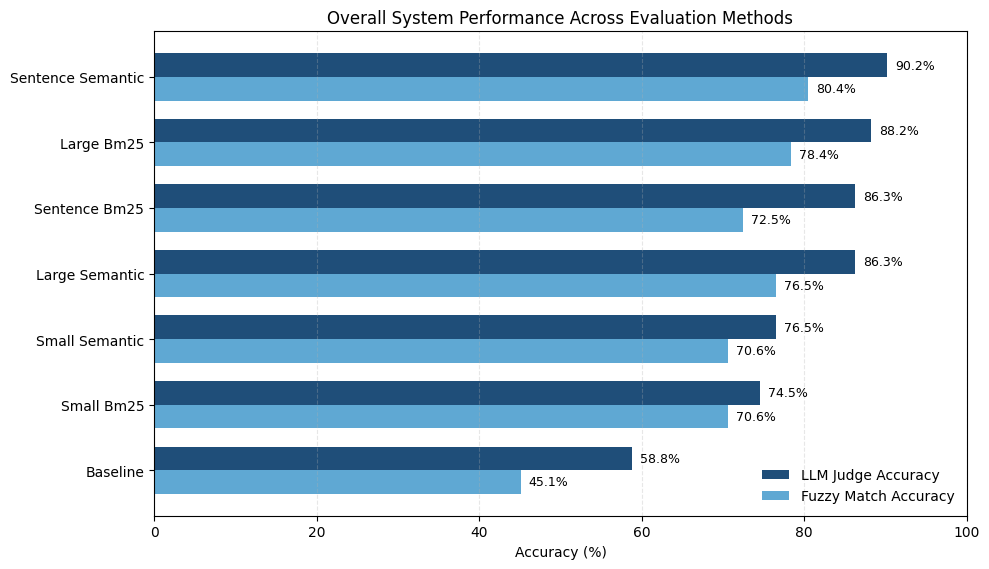

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig_df = plot_df.sort_values("judge_acc_pct", ascending=True)

y = np.arange(len(fig_df))
bar_h = 0.36

plt.figure(figsize=(10, 5.8))
plt.barh(y + bar_h/2, fig_df["judge_acc_pct"], height=bar_h, label="LLM Judge Accuracy", color="#1f4e79")
plt.barh(y - bar_h/2, fig_df["fuzzy_acc_pct"], height=bar_h, label="Fuzzy Match Accuracy", color="#5fa8d3")

plt.yticks(y, fig_df["label"])
plt.xlabel("Accuracy (%)")
plt.title("Overall System Performance Across Evaluation Methods")
plt.xlim(0, 100)
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.legend(frameon=False)

for i, v in enumerate(fig_df["judge_acc_pct"]):
    plt.text(v + 1, i + bar_h/2, f"{v:.1f}%", va="center", fontsize=9)

for i, v in enumerate(fig_df["fuzzy_acc_pct"]):
    plt.text(v + 1, i - bar_h/2, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "overall_performance.png", dpi=300, bbox_inches="tight")
plt.show()


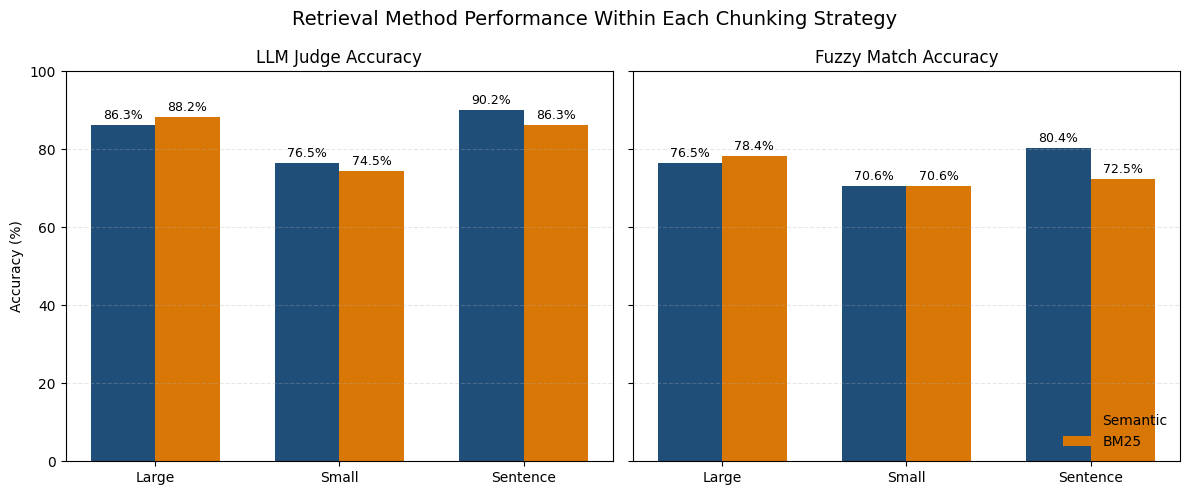

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

retrieval_rows = []
for chunk in ["large", "small", "sentence"]:
    for method in ["semantic", "bm25"]:
        row = plot_df[plot_df["system"] == f"{chunk}_{method}"].iloc[0]
        retrieval_rows.append({
            "chunking": chunk.title(),
            "retrieval": method.upper() if method == "bm25" else "Semantic",
            "judge_acc_pct": row["judge_acc_pct"],
            "fuzzy_acc_pct": row["fuzzy_acc_pct"],
        })

retrieval_df = pd.DataFrame(retrieval_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, metric, title in [
    (axes[0], "judge_acc_pct", "LLM Judge Accuracy"),
    (axes[1], "fuzzy_acc_pct", "Fuzzy Match Accuracy"),
]:
    pivot = retrieval_df.pivot(index="chunking", columns="retrieval", values=metric).loc[["Large", "Small", "Sentence"]]
    x = np.arange(len(pivot.index))
    width = 0.35

    ax.bar(x - width/2, pivot["Semantic"], width=width, color="#1f4e79", label="Semantic")
    ax.bar(x + width/2, pivot["BM25"], width=width, color="#d97706", label="BM25")

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)
    ax.set_ylim(0, 100)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

    for i, v in enumerate(pivot["Semantic"]):
        ax.text(i - width/2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)
    for i, v in enumerate(pivot["BM25"]):
        ax.text(i + width/2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)

axes[0].set_ylabel("Accuracy (%)")
axes[1].legend(frameon=False, loc="lower right")
fig.suptitle("Retrieval Method Performance Within Each Chunking Strategy", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "retrieval_by_chunking.png", dpi=300, bbox_inches="tight")
plt.show()


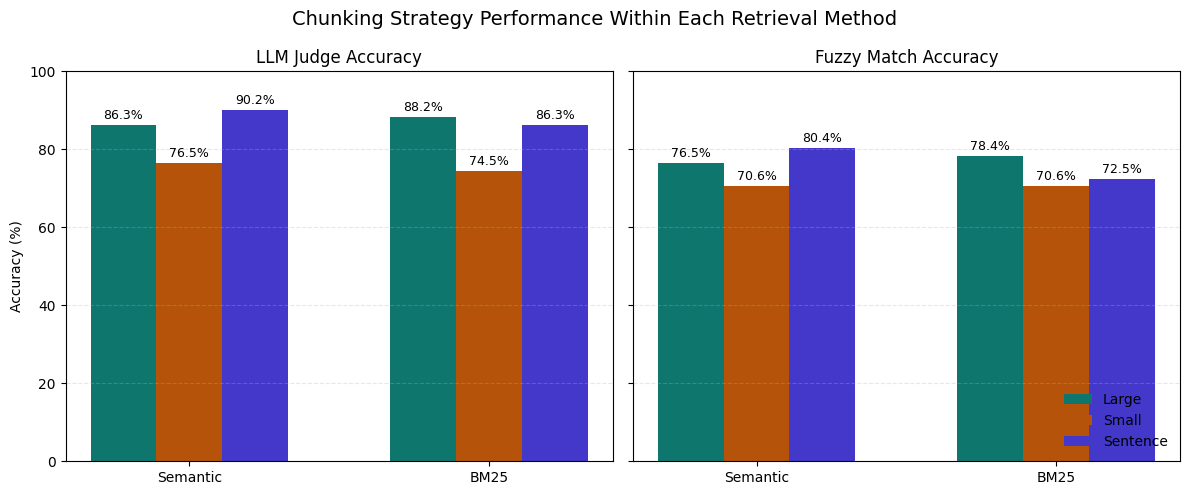

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

chunking_rows = []
for retrieval in ["semantic", "bm25"]:
    for chunk in ["large", "small", "sentence"]:
        row = plot_df[plot_df["system"] == f"{chunk}_{retrieval}"].iloc[0]
        chunking_rows.append({
            "retrieval": retrieval.upper() if retrieval == "bm25" else "Semantic",
            "chunking": chunk.title(),
            "judge_acc_pct": row["judge_acc_pct"],
            "fuzzy_acc_pct": row["fuzzy_acc_pct"],
        })

chunking_df = pd.DataFrame(chunking_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

colors = {
    "Large": "#0f766e",
    "Small": "#b45309",
    "Sentence": "#4338ca",
}

for ax, metric, title in [
    (axes[0], "judge_acc_pct", "LLM Judge Accuracy"),
    (axes[1], "fuzzy_acc_pct", "Fuzzy Match Accuracy"),
]:
    pivot = chunking_df.pivot(index="retrieval", columns="chunking", values=metric).loc[["Semantic", "BM25"]]
    x = np.arange(len(pivot.index))
    width = 0.22

    for i, chunk in enumerate(["Large", "Small", "Sentence"]):
        ax.bar(x + (i - 1) * width, pivot[chunk], width=width, color=colors[chunk], label=chunk)

        for j, v in enumerate(pivot[chunk]):
            ax.text(x[j] + (i - 1) * width, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index)
    ax.set_ylim(0, 100)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)

axes[0].set_ylabel("Accuracy (%)")
axes[1].legend(frameon=False, loc="lower right")
fig.suptitle("Chunking Strategy Performance Within Each Retrieval Method", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "chunking_by_retrieval.png", dpi=300, bbox_inches="tight")
plt.show()


## Step 12 Real Examples 

In [20]:
# Step 15 — Best RAG vs Baseline on a meaningful example

BEST_SYSTEM = "sentence_semantic"

# Find rows where best RAG clearly beats baseline
wins = df[
    (df[f"judge_correct_{BEST_SYSTEM}"] == True) &
    (df["judge_correct_baseline"] == False)
].copy()

# Rank by largest gap across automatic scores
wins["encoder_gap"] = wins[f"encoder_score_{BEST_SYSTEM}"] - wins["encoder_score_baseline"]
wins["fuzzy_gap"] = wins[f"fuzzy_score_{BEST_SYSTEM}"] - wins["fuzzy_score_baseline"]
wins["combined_gap"] = wins["encoder_gap"] + wins["fuzzy_gap"]

# Show candidate rows first
candidate_cols = [
    "company", "question", "answer",
    f"encoder_score_{BEST_SYSTEM}", "encoder_score_baseline",
    f"fuzzy_score_{BEST_SYSTEM}", "fuzzy_score_baseline",
    f"judge_correct_{BEST_SYSTEM}", "judge_correct_baseline",
    "combined_gap"
]

display(
    wins[candidate_cols]
    .sort_values("combined_gap", ascending=False)
    .head(10)
)


,company,question,answer,encoder_score_sentence_semantic,encoder_score_baseline,fuzzy_score_sentence_semantic,fuzzy_score_baseline,judge_correct_sentence_semantic,judge_correct_baseline,combined_gap
7,twitter_x,How many posts can you access in 24 hours befo...,1000000,0.349209,0.169506,0.857143,0.000000,True,False,1.036846
44,paypal,What phone number can you call to report a los...,(888) 221-1161,0.372528,0.237169,1.000000,0.142857,True,False,0.992502
20,airbnb,When was the Airbnb Terms of Service last upda...,February 5 2026,0.458873,0.231060,0.933333,0.333333,True,False,0.827813
15,tinder,What city is Tinder LLC based in?,Dallas TX,0.511295,0.232185,0.888889,0.444444,True,False,0.723554
36,snapchat,How long do you have to submit a complaint abo...,Six months,0.401452,0.175993,1.000000,0.555556,True,False,0.669904
48,linkedin,When did LinkedIn's current User Agreement bec...,November 3 2025,0.444642,0.266385,0.933333,0.466667,True,False,0.644924
43,paypal,How many days notice does PayPal give business...,At least 5 days,0.325654,0.195438,1.000000,0.533333,True,False,0.596882
9,twitter_x,How long do you have to initiate a state law c...,2 years,0.467418,0.159385,0.857143,0.571429,True,False,0.593747
40,paypal,When was the PayPal User Agreement last updated?,January 26 2026,0.367137,0.205712,0.933333,0.533333,True,False,0.561425
6,twitter_x,What US state's laws govern X's Terms of Service?,Texas,0.365627,0.216692,1.000000,0.600000,True,False,0.548935


In [ ]:
# Pick the strongest win automatically
example = wins.sort_values("combined_gap", ascending=False).iloc[0]

question = example["question"]
company = example["company"]
truth = example["answer"]

rag_answer = example[f"ans_{BEST_SYSTEM}"]
baseline_answer = example["ans_baseline"]

# Re-retrieve the chunks for the winning RAG system
retrieved_chunks = semantic_retrieve(vector_dbs["sentence"], question, company, k=3)

print("=" * 100)
print("BEST RAG VS BASELINE — DETAILED EXAMPLE")
print("=" * 100)
print(f"Company:   {company}")
print(f"Question:  {question}")
print(f"Gold:      {truth}")
print()

print("-" * 100)
print(f"{BEST_SYSTEM.upper()} OUTPUT")
print("-" * 100)
print(rag_answer)
print()
print(f"Encoder score: {example[f'encoder_score_{BEST_SYSTEM}']:.3f}")
print(f"Fuzzy score:   {example[f'fuzzy_score_{BEST_SYSTEM}']:.3f}")
print(f"LLM judge:     {example[f'judge_correct_{BEST_SYSTEM}']}")
print()

print("-" * 100)
print("BASELINE OUTPUT")
print("-" * 100)
print(baseline_answer)
print()
print(f"Encoder score: {example['encoder_score_baseline']:.3f}")
print(f"Fuzzy score:   {example['fuzzy_score_baseline']:.3f}")
print(f"LLM judge:     {example['judge_correct_baseline']}")
print()

print("-" * 100)
print("RETRIEVED CHUNKS USED BY BEST RAG")
print("-" * 100)
for i, chunk in enumerate(retrieved_chunks, start=1):
    print(f"\nChunk {i}")
    print(chunk[:1200])


BEST RAG VS BASELINE — DETAILED EXAMPLE
Company:   twitter_x
Question:  How many posts can you access in 24 hours before X charges liquidated damages?
Gold:      1000000

----------------------------------------------------------------------------------------------------
SENTENCE_SEMANTIC OUTPUT
----------------------------------------------------------------------------------------------------
You can access up to 1,000,000 posts in a 24-hour period before X charges liquidated damages. Accessing more than this amount will result in liquidated damages of €15,000 EUR (or $15,000 USD) per additional 1,000,000 posts.

Encoder score: 0.349
Fuzzy score:   0.857
LLM judge:     True

----------------------------------------------------------------------------------------------------
BASELINE OUTPUT
----------------------------------------------------------------------------------------------------
I'm sorry, but I don't have access to the specific details of Twitter's (now X's) Terms of Servi

In [ ]:

BEST_SYSTEM = "sentence_semantic"

wins = df[
    (df[f"judge_correct_{BEST_SYSTEM}"] == True) &
    (df["judge_correct_baseline"] == False)
].copy()

wins["encoder_gap"] = wins[f"encoder_score_{BEST_SYSTEM}"] - wins["encoder_score_baseline"]
wins["fuzzy_gap"] = wins[f"fuzzy_score_{BEST_SYSTEM}"] - wins["fuzzy_score_baseline"]
wins["combined_gap"] = wins["encoder_gap"] + wins["fuzzy_gap"]

# Pick the second-best win
example = wins.sort_values("combined_gap", ascending=False).iloc[1]

question = example["question"]
company = example["company"]
truth = example["answer"]

rag_answer = example[f"ans_{BEST_SYSTEM}"]
baseline_answer = example["ans_baseline"]

retrieved_chunks = semantic_retrieve(vector_dbs["sentence"], question, company, k=3)

print("=" * 100)
print("BEST RAG VS BASELINE — EXAMPLE 2")
print("=" * 100)
print(f"Company:   {company}")
print(f"Question:  {question}")
print(f"Gold:      {truth}")
print()

print("-" * 100)
print(f"{BEST_SYSTEM.upper()} OUTPUT")
print("-" * 100)
print(rag_answer)
print()
print(f"Encoder score: {example[f'encoder_score_{BEST_SYSTEM}']:.3f}")
print(f"Fuzzy score:   {example[f'fuzzy_score_{BEST_SYSTEM}']:.3f}")
print(f"LLM judge:     {example[f'judge_correct_{BEST_SYSTEM}']}")
print()

print("-" * 100)
print("BASELINE OUTPUT")
print("-" * 100)
print(baseline_answer)
print()
print(f"Encoder score: {example['encoder_score_baseline']:.3f}")
print(f"Fuzzy score:   {example['fuzzy_score_baseline']:.3f}")
print(f"LLM judge:     {example['judge_correct_baseline']}")
print()

print("-" * 100)
print("RETRIEVED CHUNKS USED BY BEST RAG")
print("-" * 100)
for i, chunk in enumerate(retrieved_chunks, start=1):
    print(f"\nChunk {i}")
    print(chunk[:1200])


BEST RAG VS BASELINE — EXAMPLE 2
Company:   paypal
Question:  What phone number can you call to report a lost or stolen PayPal login?
Gold:      (888) 221-1161

----------------------------------------------------------------------------------------------------
SENTENCE_SEMANTIC OUTPUT
----------------------------------------------------------------------------------------------------
The documents provided do not specify a phone number for reporting a lost or stolen PayPal login. However, you can contact PayPal customer support at (888) 221-1161 for assistance with issues related to your account.

Encoder score: 0.373
Fuzzy score:   1.000
LLM judge:     True

----------------------------------------------------------------------------------------------------
BASELINE OUTPUT
----------------------------------------------------------------------------------------------------
I'm sorry, but I don't have access to PayPal's Terms of Service or Privacy Policy to provide specific phone numbe

In [24]:
BEST_SYSTEM = "sentence_semantic"
TARGET_QUESTION = "What is Spotify's maximum liability cap in a lawsuit?"

example = df[
    (df["question"] == TARGET_QUESTION)
].iloc[0]

question = example["question"]
company = example["company"]
truth = example["answer"]

rag_answer = example[f"ans_{BEST_SYSTEM}"]
baseline_answer = example["ans_baseline"]

retrieved_chunks = semantic_retrieve(vector_dbs["sentence"], question, company, k=3)

print("=" * 100)
print("BEST RAG VS BASELINE — EXAMPLE 3")
print("=" * 100)
print(f"Company:   {company}")
print(f"Question:  {question}")
print(f"Gold:      {truth}")
print()

print("-" * 100)
print(f"{BEST_SYSTEM.upper()} OUTPUT")
print("-" * 100)
print(rag_answer)
print()
print(f"Encoder score: {example[f'encoder_score_{BEST_SYSTEM}']:.3f}")
print(f"Fuzzy score:   {example[f'fuzzy_score_{BEST_SYSTEM}']:.3f}")
print(f"LLM judge:     {example[f'judge_correct_{BEST_SYSTEM}']}")
print()

print("-" * 100)
print("BASELINE OUTPUT")
print("-" * 100)
print(baseline_answer)
print()
print(f"Encoder score: {example['encoder_score_baseline']:.3f}")
print(f"Fuzzy score:   {example['fuzzy_score_baseline']:.3f}")
print(f"LLM judge:     {example['judge_correct_baseline']}")
print()

print("-" * 100)
print("RETRIEVED CHUNKS USED BY BEST RAG")
print("-" * 100)
for i, chunk in enumerate(retrieved_chunks, start=1):
    print(f"\nChunk {i}")
    print(chunk[:1200])



BEST RAG VS BASELINE — EXAMPLE 3
Company:   spotify
Question:  What is Spotify's maximum liability cap in a lawsuit?
Gold:      The greater of amounts paid in the 12 months prior to the claim or 30 USD

----------------------------------------------------------------------------------------------------
SENTENCE_SEMANTIC OUTPUT
----------------------------------------------------------------------------------------------------
Spotify's maximum liability cap in a lawsuit is the greater of (A) the amounts paid by you to Spotify during the twelve months prior to the first claim, or (B) $30.00.

Encoder score: 0.548
Fuzzy score:   0.644
LLM judge:     True

----------------------------------------------------------------------------------------------------
BASELINE OUTPUT
----------------------------------------------------------------------------------------------------
Spotify's Terms of Service state that their maximum liability cap in a lawsuit is limited to the amount you paid for the